## Surfacewater data cleaning

Prepare surface water nitrate measurements data for modeling within the HUC8 watershed. 

Charlsey Tomassetti



### 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import time

from urllib.request import urlopen
import json
from urllib.parse import urlencode
from urllib.error import HTTPError

### 2. Load data

In [19]:
#load clean groundwater data
groundwater = pd.read_csv("../../groundwater_nitrate_clean.csv")

groundwater_gdf = gpd.GeoDataFrame(
    groundwater,
    geometry=gpd.points_from_xy(
        groundwater["gm_longitude"],
        groundwater["gm_latitude"]
    ),
    crs="EPSG:4326"
)

In [10]:
base_url = 'https://publish.data.ca.gov/api/3/action/datastore_search_sql'

resource_id = 'e07c5e0b-cace-4b70-9f13-b3e696cd5a99'

batch_size = 1000
offset = 0
all_records = []

while True:
    sql = f"""
    SELECT *
    FROM "{resource_id}"
    WHERE "Analyte" LIKE '%Nitrate%'
    ORDER BY "_id" ASC
    LIMIT {batch_size}
    OFFSET {offset}
    """

    url = f'{base_url}?{urlencode({"sql": sql})}'

    with urlopen(url) as response:
        result = json.load(response)["result"]

    records = result["records"]

    if not records:
        break

    all_records.extend(records)

    print(
        f"Downloaded {len(all_records)} records "
        f"(latest batch: {len(records)})"
    )

    offset += batch_size
    time.sleep(0.1)

surfacewater = pd.DataFrame(all_records)

print(f"Total records downloaded: {len(surfacewater)}")



Downloaded 1000 records (latest batch: 1000)
Downloaded 2000 records (latest batch: 1000)
Downloaded 3000 records (latest batch: 1000)
Downloaded 4000 records (latest batch: 1000)
Downloaded 5000 records (latest batch: 1000)
Downloaded 6000 records (latest batch: 1000)
Downloaded 7000 records (latest batch: 1000)
Downloaded 8000 records (latest batch: 1000)
Downloaded 9000 records (latest batch: 1000)
Downloaded 10000 records (latest batch: 1000)
Downloaded 11000 records (latest batch: 1000)
Downloaded 12000 records (latest batch: 1000)
Downloaded 13000 records (latest batch: 1000)
Downloaded 14000 records (latest batch: 1000)
Downloaded 15000 records (latest batch: 1000)
Downloaded 16000 records (latest batch: 1000)
Downloaded 17000 records (latest batch: 1000)
Downloaded 18000 records (latest batch: 1000)
Downloaded 19000 records (latest batch: 1000)
Downloaded 20000 records (latest batch: 1000)
Downloaded 21000 records (latest batch: 1000)
Downloaded 22000 records (latest batch: 100

In [11]:
# Load HUC8 watershed boundary
gdb = Path("..") / ("..") / ("NHD_H_18060005_HU8_GDB") / "NHD_H_18060005_HU8_GDB.gdb"

huc8 = gpd.read_file(
    gdb,
    layer="WBDHU8"
)

huc8.head()


,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
0,{2EB2E16D-AA63-432F-9DC1-1820721507ED},None,None,None,None,2012-06-11 07:54:57+00:00,None,2130628.5,8622.36,CA,18060005,Salinas,7.476846,0.862215,"MULTIPOLYGON (((-121.79903 36.74909, -121.7986..."


In [12]:
# Convert surfacewater coordinates to geographic points
surfacewater_gdf = gpd.GeoDataFrame(
    surfacewater,
    geometry=gpd.points_from_xy(
        surfacewater["Longitude"],
        surfacewater["Latitude"]
    ),
    crs="EPSG:4326"
)

In [13]:
print(surfacewater_gdf.crs)
print(huc8.crs)

EPSG:4326
EPSG:4269


In [14]:
huc8 = huc8.to_crs(surfacewater_gdf.crs)

In [15]:
#clipping points to watershed boundary
surfacewater_huc8 = gpd.clip(
    surfacewater_gdf,
    huc8
)

In [16]:
#verify that clipping was successful
print("Original surfacewater records:", len(surfacewater_gdf))
print("Records inside HUC8:", len(surfacewater_huc8))

surfacewater_huc8.head()

Original surfacewater records: 23351
Records inside HUC8: 635


,_id,_full_text,Program,ParentProject,Project,StationName,StationCode,SampleDate,CollectionTime,LocationCode,...,ParentProjectCode,ProjectCode,MatrixCode,AnalyteCode,FractionName,FractionCode,DataQuality,DataQualityIndicator,Datum,geometry
16365,731964,"'-01':74,75,79,80 '-04':26 '-05':25,87,88,93,9...",Monterey Bay National Marine Sanctuary Water Q...,MBNMS Snapshot Day,MBNMS_Snapshot_Day,Trout Creek at 3 bridges,309-TROUT-41,2019-05-04,10:50,Not Recorded,...,MBNMS_SSD,MBNMS_SSD,5,69,Not Recorded,1,Unknown data quality,BatchVerification:NR; QACode:NR,WGS84,POINT (-120.58188 35.38849)
2030,56661,"'-01':26,79,80,84,85,91,92 '-02':98 '-03':42,1...",Monterey Bay National Marine Sanctuary Water Q...,MBNMS Snapshot Day,MBNMS_Snapshot_Day,Trout Creek at 3 bridges,309-TROUT-41,2021-05-01,08:58,Not Recorded,...,MBNMS_SSD,MBNMS_SSD,5,69,Dissolved,3,Unknown data quality,BatchVerification:NR,WGS84,POINT (-120.58188 35.38849)
16237,731836,"'-01':74,75,79,80 '-05':25,87,93 '-06':26,88,9...",Monterey Bay National Marine Sanctuary Water Q...,MBNMS Snapshot Day,MBNMS_Snapshot_Day,Trout Creek at 3 bridges,309-TROUT-41,2017-05-06,10:02,Not Recorded,...,MBNMS_SSD,MBNMS_SSD,5,69,Not Recorded,1,Unknown data quality,BatchVerification:NR; QACode:NR,WGS84,POINT (-120.58188 35.38849)
9225,390883,"'-01':25,80,81,85,86,92,93 '-02':98 '-121.2051...",Central Coast Coop Monitoring Program for Ag,RWB3 Cooperative Monitoring Program,RWB 3 Cooperative Monitoring Program,Salinas River Elm Road in Greenfield,309GRN,2025-01-29,07:45,"Bank, Left",...,RWB3_CMP,RWB3_CMP,5,66,Total,2,Unknown data quality,BatchVerification:NR,NAD83,POINT (-121.20518 36.33769)
9357,392291,"'-01':83,84,88,89,95,96 '-05':25 '-06':101 '-1...",Central Coast Coop Monitoring Program for Ag,RWB3 Cooperative Monitoring Program,RWB 3 Cooperative Monitoring Program,Salinas River Elm Road in Greenfield,309GRN,2025-05-27,08:00,"Bank, Left",...,RWB3_CMP,RWB3_CMP,5,66,Total,2,Unknown data quality,BatchVerification:NR,NAD83,POINT (-121.20518 36.33769)


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

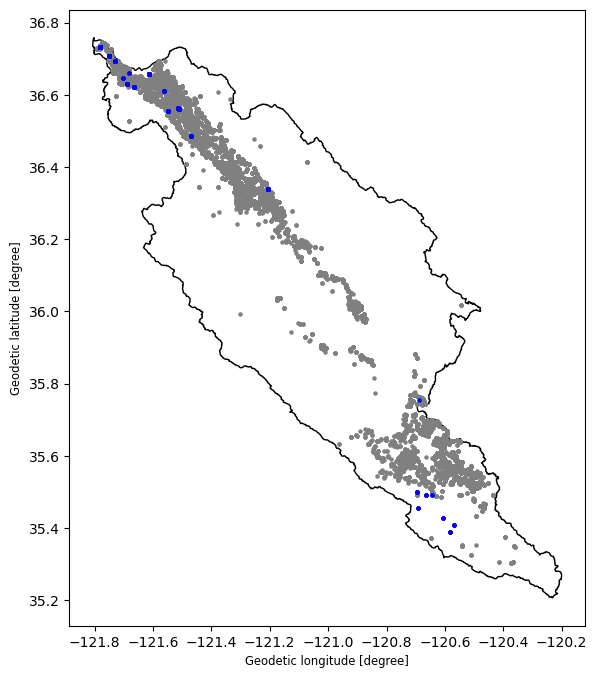

In [21]:
#verify that clipping was successful

ax = huc8.plot(
    figsize=(10, 8),
    facecolor="none",
    edgecolor="black"
)

groundwater_gdf.plot(
    ax=ax,
    color="grey",
    markersize=5
)

surfacewater_huc8.plot(
    ax=ax,
    color="blue",
    markersize=5
)

